In [2]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
# Load ZIP file
zip_path = r"/content/drive/MyDrive/archive.zip"
with zipfile.ZipFile(zip_path, 'r') as z:

    # Load raw CSV files
    orders = pd.read_csv(z.open('olist_orders_dataset.csv'))
    reviews = pd.read_csv(z.open('olist_order_reviews_dataset.csv'))
    customers = pd.read_csv(z.open('olist_customers_dataset.csv'))

# Check dimensions
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)


In [ ]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [ ]:
reviews

In [ ]:
customers

NameError: name 'customers' is not defined

In [ ]:
# Check uniqueness of keys
print("Unique order_id in Orders:", orders['order_id'].nunique())
print("Unique order_id in Reviews:", reviews['order_id'].nunique())
print("Unique customer_id in Customers:", customers['customer_id'].nunique())

Unique order_id in Orders: 99441
Unique order_id in Reviews: 98673
Unique customer_id in Customers: 99441


In [ ]:
# Keep first review per order
reviews_clean = reviews.drop_duplicates(subset='order_id')
print("Reviews cleaned shape:", reviews_clean.shape)

Reviews cleaned shape: (98673, 7)


In [ ]:
master_df = orders.merge(
    reviews_clean,
    on='order_id',
    how='left'
)
print("After Orders + Reviews:", master_df.shape)

After Orders + Reviews: (99441, 14)


In [ ]:
master_df = master_df.merge(
    customers,
    on='customer_id',
    how='left'
)
print("Final master dataset shape:", master_df.shape)

Final master dataset shape: (99441, 18)


In [ ]:
# Compare rows before and after joins
print("Original Orders rows:", len(orders))
print("Final Master rows:", len(master_df))
assert len(master_df) == len(orders), \
    "Warning: Row duplication detected!"

Original Orders rows: 99441
Final Master rows: 99441


In [ ]:
master_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,e262b3f92d1ce917aa412a9406cf61a6,5.0,NaN,NaN,2017-03-22 00:00:00,2017-03-23 11:02:08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,371579771219f6db2d830d50805977bb,5.0,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [ ]:
# Convert date columns
orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

In [ ]:
#Handle missing deliveries
orders['Delivery_Status'] = 'Delivered'
orders.loc[
    orders['order_status'].isin(['canceled', 'unavailable']),
    'Delivery_Status'
] = 'Not Delivered'

In [ ]:
#Create the delay calculation
orders['Days_Difference'] = (
    orders['order_estimated_delivery_date']
    - orders['order_delivered_customer_date']
).dt.days

In [ ]:
orders['Days_Difference']

,Days_Difference
0,7.0
1,5.0
2,17.0
3,12.0
4,9.0
...,...
99436,10.0
99437,1.0
99438,5.0
99439,20.0


In [ ]:
#Classify delivery performance
def classify_delivery(row):
    if row['Delivery_Status'] == 'Not Delivered':
        return 'Not Delivered'
    days = row['Days_Difference']
    if days >= 0:
        return 'On Time'
    elif -5 <= days < 0:
        return 'Late'
    else:
        return 'Super Late'
orders['Delay_Category'] = orders.apply(
    classify_delivery,
    axis=1
)

In [ ]:
orders['Delay_Category']

,Delay_Category
0,On Time
1,On Time
2,On Time
3,On Time
4,On Time
...,...
99436,On Time
99437,On Time
99438,On Time
99439,On Time


In [ ]:
#Validate results
print(
    orders[['order_id',
            'order_status',
            'order_estimated_delivery_date',
            'order_delivered_customer_date',
            'Days_Difference',
            'Delay_Category']].head(10)
)

                           order_id order_status  \
0  e481f51cbdc54678b7cc49136f2d6af7    delivered   
1  53cdb2fc8bc7dce0b6741e2150273451    delivered   
2  47770eb9100c2d0c44946d9cf07ec65d    delivered   
3  949d5b44dbf5de918fe9c16f97b45f8a    delivered   
4  ad21c59c0840e6cb83a9ceb5573f8159    delivered   
5  a4591c265e18cb1dcee52889e2d8acc3    delivered   
6  136cce7faa42fdb2cefd53fdc79a6098     invoiced   
7  6514b8ad8028c9f2cc2374ded245783f    delivered   
8  76c6e866289321a7c93b82b54852dc33    delivered   
9  e69bfb5eb88e0ed6a785585b27e16dbf    delivered   

  order_estimated_delivery_date order_delivered_customer_date  \
0                    2017-10-18           2017-10-10 21:25:13   
1                    2018-08-13           2018-08-07 15:27:45   
2                    2018-09-04           2018-08-17 18:06:29   
3                    2017-12-15           2017-12-02 00:28:42   
4                    2018-02-26           2018-02-16 18:17:02   
5                    2017-08-01      

In [ ]:
#Summary statistics
print(
    orders['Delay_Category'].value_counts(dropna=False)
)

Delay_Category
On Time          88644
Super Late        5948
Late              3615
Not Delivered     1234
Name: count, dtype: int64


In [ ]:
#Exclude non-delivered orders from analysis
delivered_orders = orders[
    ~orders['order_status'].isin(['canceled', 'unavailable'])
]

In [ ]:
#Use only delivered orders
delivered_orders = orders[
    orders['Delay_Category'] != 'Not Delivered'
].copy()

In [ ]:
#We want to calculate late delivery percentage by state
delivered_orders['Late_Flag'] = delivered_orders[
    'Delay_Category'
].isin(['Late','Super Late'])

In [ ]:
#Join customer_state
orders_customers = delivered_orders.merge(
    customers[['customer_id','customer_state']],
    on='customer_id',
    how='left'
)

In [ ]:
#Calculate % Late Orders by State
state_delay = orders_customers.groupby(
    'customer_state'
).agg(
    Total_Orders=('order_id','count'),
    Late_Orders=('Late_Flag','sum')
)
state_delay['Late_Percentage'] = (
    state_delay['Late_Orders']
    / state_delay['Total_Orders']
) * 100
state_delay = state_delay.sort_values(
    'Late_Percentage',
    ascending=False
)
print(state_delay.head(10))

                Total_Orders  Late_Orders  Late_Percentage
customer_state                                            
AL                       411          109        26.520681
MA                       736          160        21.739130
RR                        45            9        20.000000
PI                       490           90        18.367347
CE                      1323          240        18.140590
SE                       345           61        17.681159
BA                      3344          545        16.297847
RJ                     12698         2012        15.845015
PA                       969          140        14.447884
TO                       278           39        14.028777


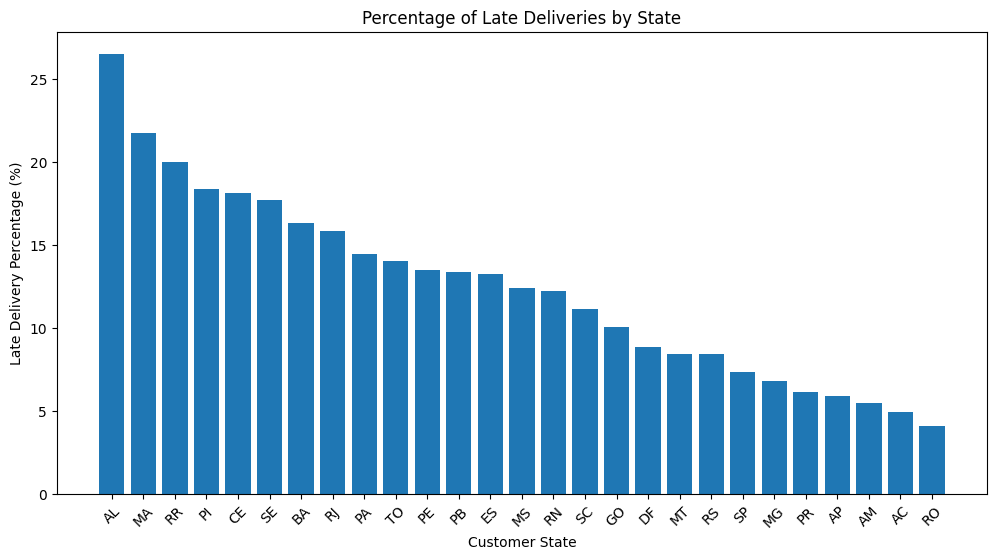

In [ ]:
#Visualize — Bar Chart
plt.figure(figsize=(12,6))
plt.bar(
    state_delay.index,
    state_delay['Late_Percentage']
)
plt.xticks(rotation=45)
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Percentage (%)")
plt.title("Percentage of Late Deliveries by State")
plt.show()

In [ ]:
#Identify Worst Regions
print(
    state_delay[['Late_Percentage']]
    .head(10)
)

                Late_Percentage
customer_state                 
AL                    26.520681
MA                    21.739130
RR                    20.000000
PI                    18.367347
CE                    18.140590
SE                    17.681159
BA                    16.297847
RJ                    15.845015
PA                    14.447884
TO                    14.028777


In [ ]:
#Business Insight — Are Remote States Affected?
remote_states = [
    'AM','AC','RR','AP','RO','PA','TO'
]

In [ ]:
#Create comparison:
state_delay['Region_Type'] = 'Non-Remote'
state_delay.loc[
    state_delay.index.isin(remote_states),
    'Region_Type'
] = 'Remote'

In [ ]:
#Average lateness:
remote_analysis = state_delay.groupby(
    'Region_Type'
)['Late_Percentage'].mean()
print(remote_analysis)

Region_Type
Non-Remote    13.324799
Remote         9.829215
Name: Late_Percentage, dtype: float64


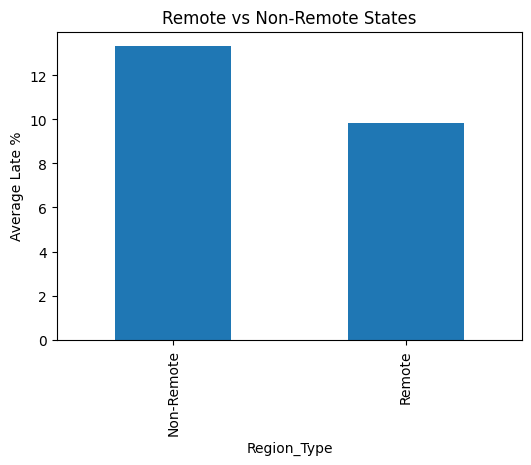

In [ ]:
#Remote vs Non-Remote
remote_analysis.plot(
    kind='bar',
    figsize=(6,4)
)
plt.ylabel("Average Late %")
plt.title("Remote vs Non-Remote States")
plt.show()

In [ ]:
#Build a combined dataset
# Join orders with reviews
sentiment_df = orders.merge(
    reviews[['order_id','review_score']],
    on='order_id',
    how='left'
)

In [ ]:
sentiment_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,5.0
...,...,...,...,...,...,...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,5.0
99988,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,4.0
99989,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,5.0
99990,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2.0


In [ ]:
sentiment_df.shape

(99992, 9)

In [ ]:
# Convert date columns
orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)
# Create Days_Difference column
orders['Days_Difference'] = (
    orders['order_estimated_delivery_date']
    - orders['order_delivered_customer_date']
).dt.days
# Create Delay_Category
def classify_delivery(days):
    if pd.isna(days):
        return 'Not Delivered'
    elif days >= 0:
        return 'On Time'
    elif -5 <= days < 0:
        return 'Late'
    else:
        return 'Super Late'
orders['Delay_Category'] = orders[
    'Days_Difference'
].apply(classify_delivery)

In [ ]:
# Join orders + reviews
sentiment_df = orders.merge(
    reviews[['order_id','review_score']],
    on='order_id',
    how='left'
)
# Delivery delay as positive late days
sentiment_df['Delivery_Delay_Days'] = (
    sentiment_df['Days_Difference'] * -1
)
sentiment_df['Delivery_Delay_Days'] = sentiment_df[
    'Delivery_Delay_Days'
].clip(lower=0)

In [ ]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'Days_Difference', 'Delay_Category'],
      dtype='object')

In [ ]:
# Load datasets from archive.zip

with zipfile.ZipFile(zip_path,'r') as z:

    products = pd.read_csv(
        z.open('olist_products_dataset.csv')
    )

    translation = pd.read_csv(
        z.open('product_category_name_translation.csv')
    )

In [ ]:
print(products.head())
print(translation.head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [ ]:
# Merge translation table
products_en = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

In [ ]:
#Handle missing translations
products_en[
    'product_category_name_english'
] = products_en[
    'product_category_name_english'
].fillna('Unknown')

In [ ]:
#Join products into your analysis dataset
with zipfile.ZipFile(zip_path,'r') as z:
    order_items = pd.read_csv(
        z.open('olist_order_items_dataset.csv')
    )

In [ ]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [ ]:
product_analysis = order_items.merge(
    products_en[
        ['product_id',
         'product_category_name_english']
    ],
    on='product_id',
    how='left'
)

In [ ]:
#Connect with delay/review analysis
category_analysis = product_analysis.merge(
    orders[
        ['order_id',
         'Delay_Category',
         'Days_Difference']
    ],
    on='order_id',
    how='left'
)

In [ ]:
#Analyze late deliveries by product category
category_performance = category_analysis.groupby(
    'product_category_name_english'
).agg(
    Orders=('order_id','count'),
    Avg_Delay=('Days_Difference','mean')
)
category_performance = category_performance.sort_values(
    'Avg_Delay'
)
print(category_performance.head(20))

                                   Orders  Avg_Delay
product_category_name_english                       
arts_and_craftmanship                  24   5.791667
furniture_mattress_and_upholstery      38   6.162162
home_comfort_2                         30   7.433333
home_confort                          434   8.811189
food                                  510   8.867735
audio                                 364   9.149171
fashion_underwear_beach               131   9.929134
electronics                          2767  10.139978
books_imported                         60  10.192982
construction_tools_lights             304  10.222591
fashio_female_clothing                 48  10.288889
books_technical                       267  10.307985
cine_photo                             72  10.328571
diapers_and_hygiene                    39  10.351351
Unknown                              1627  10.380372
telephony                            4545  10.382619
auto                                 4235  10.

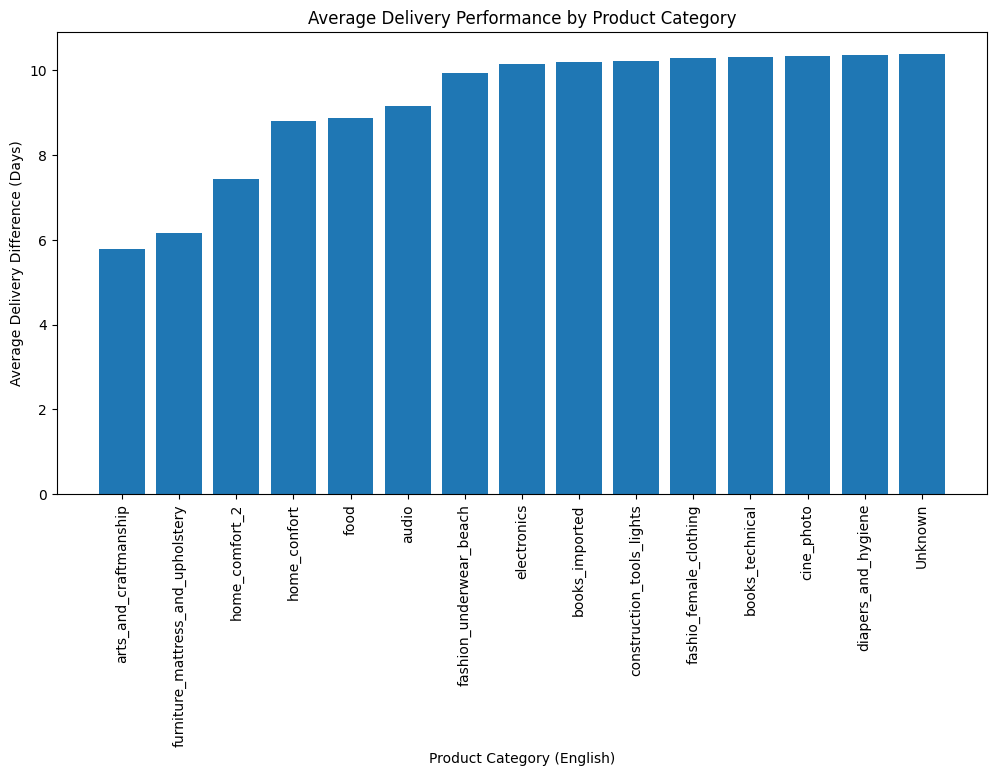

In [ ]:
top_categories = category_performance.head(15)
plt.figure(figsize=(12,6))
plt.bar(
    top_categories.index,
    top_categories['Avg_Delay']
)
plt.xticks(rotation=90)
plt.xlabel("Product Category (English)")
plt.ylabel("Average Delivery Difference (Days)")
plt.title(
    "Average Delivery Performance by Product Category"
)
plt.show()

Candidate's Choice Challenge: Revenue at Risk from Late Deliveries
Business Question

"How much revenue is associated with late deliveries?"

This moves beyond counting delays and measures financial impact.

A CEO cares more about:

"Which delays hurt revenue?"
than
"How many deliveries were late?"

In [ ]:
with zipfile.ZipFile(zip_path,'r') as z:
    payments = pd.read_csv(
        z.open('olist_order_payments_dataset.csv')
    )

In [ ]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [ ]:
#Calculate total order value
payment_summary = payments.groupby(
    'order_id'
).agg(
    Order_Value=('payment_value','sum')
).reset_index()

In [ ]:
payment_summary

,order_id,Order_Value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,386.53
99437,fffce4705a9662cd70adb13d4a31832d,116.85
99438,fffe18544ffabc95dfada21779c9644f,64.71


In [ ]:
#Join with delivery analysis
revenue_analysis = orders.merge(
    payment_summary,
    on='order_id',
    how='left'
)

In [ ]:
#Revenue by delivery status
revenue_summary = revenue_analysis.groupby(
    'Delay_Category'
).agg(
    Orders=('order_id','count'),
    Total_Revenue=('Order_Value','sum'),
    Avg_Order_Value=('Order_Value','mean')
)
print(revenue_summary.round(2))

                Orders  Total_Revenue  Avg_Order_Value
Delay_Category                                        
Late              3615      576577.66           159.50
Not Delivered     2965      587040.69           197.99
On Time          88649    14070140.55           158.72
Super Late        4212      775113.22           184.07


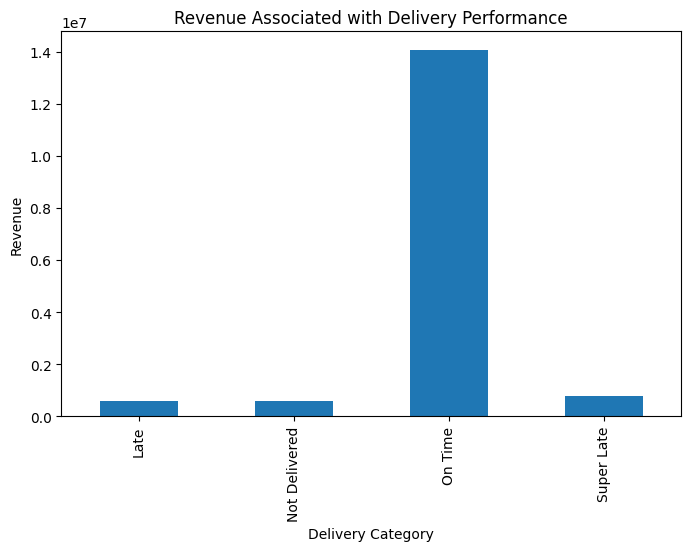

In [ ]:
#Visualization:Revenue Impact
import matplotlib.pyplot as plt
revenue_summary['Total_Revenue'].plot(
    kind='bar',
    figsize=(8,5)
)
plt.xlabel("Delivery Category")
plt.ylabel("Revenue")
plt.title(
    "Revenue Associated with Delivery Performance"
)
plt.show()

In [ ]:
#High-Value Orders at Risk
high_value_late = revenue_analysis[
    (revenue_analysis['Delay_Category']
     .isin(['Late','Super Late'])) &
    (revenue_analysis['Order_Value'] > 500)
]
print(
    high_value_late[
        ['order_id',
         'Order_Value',
         'Delay_Category']
    ].head(10)
)

                              order_id  Order_Value Delay_Category
407   da8be3bb62e9bf01e2e1a3bfd74ebd1a      2751.24           Late
453   f30607daae66843552e00843c6de88ef       695.99     Super Late
456   4f7ce3efe568a5e57290a9fa3e45b1f5      1727.67     Super Late
702   8a0b2bc5c7a1c524635f4de8bae9dffe      1008.30     Super Late
916   8b37f436aea079bd73bbcbe103d14a0b       594.55           Late
1042  5e8d0f2f1e06e715aee3eefe4c175e52       619.34     Super Late
1103  4b80b55b32a3549ec05578e46a0f4021      1291.39           Late
1206  2640506a4584f571430195e2fa215406       590.08           Late
1356  774b8c52e2dda4cae042a9175258ab1b       731.37           Late
1567  790512cc033ced5f8fe1f9158eb8f2fe       504.35     Super Late
